# Computer Vision Project - Image Classification 
## Preprocessing - Modeling - Evaluation

## 1. Introduction

This project focuses on image classification using the CIFAR-10 dataset, a widely used benchmark in computer vision. The task is a multiclass classification problem where each image must be assigned to one of ten mutually exclusive categories, including airplanes, automobiles, birds, cats, dogs, ships, and trucks.

Although CIFAR-10 is a relatively small dataset in terms of image size, it presents several challenges. The images are only 32×32 pixels, many objects occupy a small portion of the frame, and substantial variability exists in background, viewpoint, lighting conditions, and object appearance. These characteristics make accurate classification difficult and require models capable of learning robust visual representations.

The project compares two different approaches. First, a custom Convolutional Neural Network (CNN) is trained directly on the original 32×32 images to establish a baseline. Second, a transfer learning approach based on ResNet50 pretrained on ImageNet is implemented and fine-tuned for the CIFAR-10 classification task.

The workflow includes data preparation, preprocessing, model training, evaluation, and error analysis. Particular attention is given to transfer learning, data augmentation, selective fine-tuning, and model generalization. The final objective is not only to achieve strong classification performance, but also to understand how different modeling choices affect the results and where the model still struggles to make correct predictions.


## 2. Imports and Setup

#### Import Libraries

In [52]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

# Reproducibility
tf.random.set_seed(3)
np.random.seed(3)

## 3. Dataset Loading and Sampling

#### Load CIFAR-10

The training set is limited to 10,000 images to reduce training time and memory usage on local hardware. This makes experimentation and model comparison faster while still keeping the dataset large enough for meaningful evaluation.

In [2]:
# Load CIFAR-10 dataset
(train_images_32, train_labels_32), (test_images_32, test_labels_32) = cifar10.load_data()

print("Training set:", train_images_32.shape, train_labels_32.shape)
print("Test set:", test_images_32.shape, test_labels_32.shape)


Training set: (50000, 32, 32, 3) (50000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)


In [3]:
# Apply the 10k cap to the training set
N = 10000
train_images_32 = train_images_32[:N]
train_labels_32 = train_labels_32[:N]

# Inspect shape
print("Training set after cap:", train_images_32.shape, train_labels_32.shape)

Training set after cap: (10000, 32, 32, 3) (10000, 1)


In [5]:
train_images_32, val_images_32, train_labels_32, val_labels_32 = train_test_split(
    train_images_32,
    train_labels_32,
    test_size=0.2,
    random_state=3,
    stratify=train_labels_32
)

### 3.1 Resize to 224 x 224

In [6]:
def batch_resize(images, size=(224, 224), batch_size=512):
    out = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        resized = tf.image.resize(batch, size).numpy()
        out.append(resized)
    return np.concatenate(out, axis=0)

In [7]:
# Resize train, validation, and test images
train_224 = batch_resize(train_images_32)
val_224   = batch_resize(val_images_32)
test_224  = batch_resize(test_images_32)

In [9]:
# Save resized datasets
np.save("../data/train_224.npy", train_224)
np.save("../data/val_224.npy", val_224)
np.save("../data/test_224.npy", test_224)

# Save labels
np.save("../data/train_labels.npy", train_labels_32)
np.save("../data/val_labels.npy", val_labels_32)
np.save("../data/test_labels.npy", test_labels_32)

### 3.2 Load 224x224 Images

In [10]:
# LOAD
def load_in_batches(path, batch_size=2000):
    # mmap_mode='r' to avoid loading the whole file in RAM 
    arr = np.load(path, mmap_mode='r')
    out = []
    for i in range(0, len(arr), batch_size):
        out.append(arr[i:i+batch_size].copy()) 
    return np.concatenate(out, axis=0)

**Note**: The resized 224×224 images are loaded in small batches using memory mapping (`mmap_mode='r'`).  
This avoids loading the entire dataset into RAM at once and helps keep the system stable during preprocessing.

In [11]:
train_images = load_in_batches("../data/train_224.npy")
train_labels = load_in_batches("../data/train_labels.npy")

In [12]:
val_images   = load_in_batches("../data/val_224.npy")
val_labels   = load_in_batches("../data/val_labels.npy")

In [13]:
test_images  = load_in_batches("../data/test_224.npy")
test_labels  = load_in_batches("../data/test_labels.npy")

## 4. Basic Normalization

In [14]:
# Normalization batch 
def batch_normalize(images, batch_size=2000):
    out = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size].astype("float32") / 255.0
        out.append(batch)
    return np.concatenate(out, axis=0)

**Note**: The 224×224 images are normalized in batches (float32 / 255.0) to avoid processing a very large array in one step.
The 32×32 images are normalized separately because they are used by the CNN baseline, which does not need extra preprocessing.

Normalization improves numerical stability during training and helps the optimizer converge more efficiently.

In [15]:
# Normalizing 224x224 train images
train_images = batch_normalize(train_images) 

In [16]:
# Normalize 224x224 validation images
val_images = batch_normalize(val_images)

In [17]:
# Normalizing 224x224 test images
test_images  = batch_normalize(test_images)

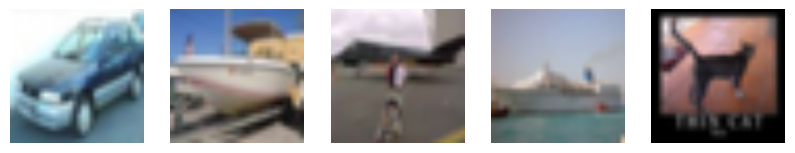

In [18]:
# Plot 224x224 images
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images[i])
    plt.axis("off")
plt.show()

Convert pixel values to the 0-1 range.

#### Normalizing 32x32 Images

In [19]:
# Normalize pixel values to the 0–1 range
train_images_32 = train_images_32.astype("float32") / 255.0
val_images_32   = val_images_32.astype("float32") / 255.0
test_images_32  = test_images_32.astype("float32") / 255.0

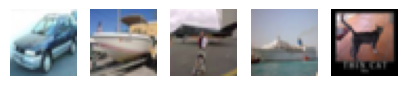

In [20]:
# Plot 32x32 images
plt.figure(figsize=(5, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images_32[i])
    plt.axis("off")
plt.show()

## 5. tf.data Pipelines

The following `tf.data` pipelines prepare the training, validation, and test datasets for efficient model training.

For the ResNet50 workflow, images are resized to 224×224 and preprocessed using the ResNet50 `preprocess_input()` function.  
Data augmentation is applied only to the training set to help reduce overfitting.

Each dataset is batched, shuffled when appropriate, and prefetched to improve throughput and training efficiency.

Using `tf.data` pipelines also improves performance by preparing data asynchronously while the GPU/CPU processes the current batch.

#### tf.data 

In [21]:
def resize_and_preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = preprocess_input(image * 255.0)
    return image, label

In [22]:
def data_augmentation(image, label):
    # Horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # Zoom/random cut to avoid overfitting
    image = tf.image.resize_with_crop_or_pad(image, 250, 250) 
    image = tf.image.random_crop(image, size=[224, 224, 3])   
    
    # brightness contrast
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    return image, label


In [23]:
# defining a callback
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # 1/2 LR
    
    patience = 2, # wait 2 epochs
    verbose = 1
)

#### tf.data 224x224 Images

In [24]:
ds_train = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .shuffle(len(train_images))
    .map(resize_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)  # Augmentation to avoid overfitting
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

In [25]:
ds_val = (
    tf.data.Dataset.from_tensor_slices((val_images, val_labels))
    .map(resize_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

In [26]:
ds_test = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .map(resize_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

#### tf.data 32x32 Images

In [27]:
ds_train_32 = (
    tf.data.Dataset.from_tensor_slices((train_images_32, train_labels))
    .shuffle(len(train_images_32))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

In [28]:
ds_val_32 = (
    tf.data.Dataset.from_tensor_slices((val_images_32, val_labels))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

In [29]:
ds_test_32 = (
    tf.data.Dataset.from_tensor_slices((test_images_32, test_labels))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

## 6 Baseline CNN

### 6.1 Baseline CNN Architecture

Define a simple convolutional model to establish a baseline.

In [30]:
def build_cnn_baseline(input_shape=(32, 32, 3), num_classes=10):
    """
    Defines a simple CNN baseline model for CIFAR-10.
    This model is intentionally lightweight and serves as a reference point
    before applying transfer learning with ResNet50.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


### 6.2 Training CNN

Train the CNN on the 10k training set 32x32 Images.

In [31]:
# Compile the baseline CNN model
cnn = build_cnn_baseline()

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

**Note**: This baseline CNN is a relatively small and lightweight model with about 357k trainable parameters.

The architecture contains three convolutional blocks.  
Each block applies:
- a convolution layer to extract image features,
- followed by max pooling to reduce spatial dimensions.

As the spatial resolution decreases (32×32 → 16×16 → 8×8 → 4×4), the number of feature maps increases (32 → 64 → 128), allowing the model to learn more complex visual patterns.

The extracted features are flattened and passed through a small fully connected classifier with Dropout regularization before the final 10-class softmax output layer.

This CNN serves as a simple baseline model before applying transfer learning with ResNet50.

In [32]:
history_cnn = cnn.fit(
    ds_train_32,
    epochs=10,
    validation_data=ds_val_32,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2499 - loss: 2.0275 - val_accuracy: 0.3865 - val_loss: 1.7420
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3651 - loss: 1.7033 - val_accuracy: 0.4390 - val_loss: 1.5604
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4372 - loss: 1.5277 - val_accuracy: 0.4675 - val_loss: 1.4437
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4834 - loss: 1.4128 - val_accuracy: 0.5160 - val_loss: 1.3315
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5241 - loss: 1.3066 - val_accuracy: 0.5375 - val_loss: 1.2724
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5550 - loss: 1.2261 - val_accuracy: 0.5470 - val_loss: 1.2568
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5964 - loss: 1.1178 - val_accuracy: 0.5850 - val_loss: 1.1722
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6255 - loss: 1.0558 - val_accu

**Note**:  The baseline CNN showed steady learning progress across the 10 training epochs.

Training accuracy improved from about 25% to nearly 68%, while validation accuracy increased to around 61%.

The validation loss generally decreased during training, showing that the model was able to learn useful image features from the dataset.

However, the growing gap between training and validation accuracy during the later epochs suggests moderate overfitting, which is common for CNN models trained on relatively small datasets.

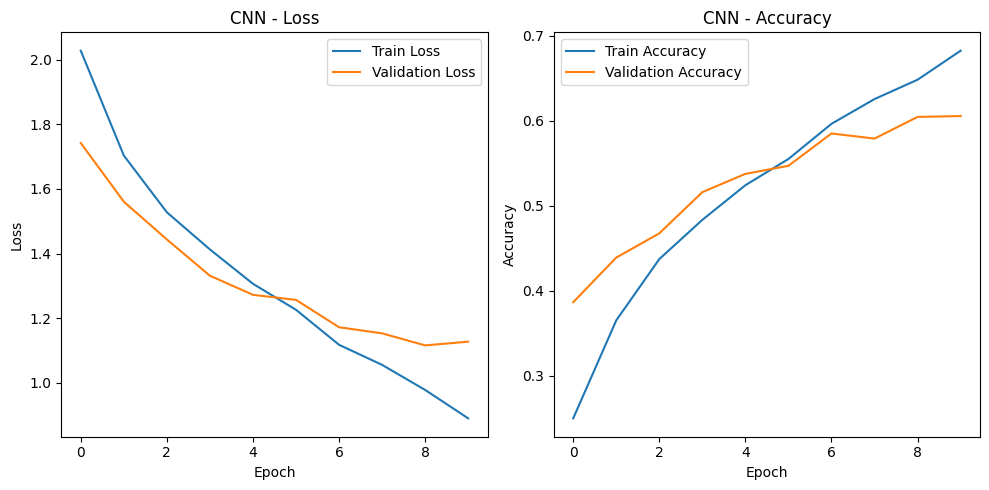

In [33]:
plt.figure(figsize=(10, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title('CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title('CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

### 6.3 Evaluation of CNN Model

In [35]:
print("Baseline CNN - Train Evaluation")
train_eval = cnn.evaluate(ds_train_32, verbose=0)

print("Train Loss:", train_eval[0])
print("Train Accuracy:", train_eval[1])

print("\nBaseline CNN - Final Test Evaluation")
test_eval = cnn.evaluate(ds_test_32, verbose=0)

print("Test Loss:", test_eval[0])
print("Test Accuracy:", test_eval[1])

Baseline CNN - Train Evaluation
Train Loss: 0.7061839699745178
Train Accuracy: 0.7637500166893005

Baseline CNN - Final Test Evaluation
Test Loss: 1.1333287954330444
Test Accuracy: 0.6051999926567078


**Note**:mThe baseline CNN achieved about 76% training accuracy and 60.5% test accuracy.

The gap between training and test performance suggests moderate overfitting, which is expected when training a relatively small CNN on a limited dataset.

Despite its simple architecture, the model was still able to learn useful visual patterns from the CIFAR-10 images. However, its performance remained clearly below the later transfer learning approach based on ResNet50.

This baseline provides an important reference point for evaluating the impact of deeper pretrained models.

## 7. ResNet50 Transfer Learning

In [36]:
# Load a pretrained ResNet50 backbone without the original classification head
def build_resnet50_base(input_shape=(224, 224, 3)):
    """
    Builds a ResNet50 base model with configurable input shape.
    The base is loaded with ImageNet weights and without the top classifier.
    """
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False
    return base_model


### 7.1 Custom Classification Head 224 x 224

#### Build Custom Head

In [37]:
# Add a custom classification head on top of the pretrained ResNet50 base
def build_resnet50_model(input_shape=(224, 224, 3), num_classes=10):
    """
    Builds a full model consisting of:
    - a frozen ResNet50 backbone pretrained on ImageNet
    - a custom classification head for CIFAR-10
    """
    base_model = build_resnet50_base(input_shape)

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)   # keep batchnorm frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model


### 7.2 Training Only the Head (10 Epochs)

Train only the custom classification head while keeping ResNet50 frozen.


#### Train head on Original

In [38]:
# Compile the model for head-only training
resnet_model = build_resnet50_model()

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Note**: This model uses a ResNet50 backbone pretrained on ImageNet.

During this stage, the entire ResNet50 base remains frozen, so only the custom classification head is trained.  
The trainable head contains:
- a Global Average Pooling layer,
- a Dense layer with 256 neurons,
- Dropout regularization,
- and a final 10-class softmax output layer.

Although the full model contains about 24 million parameters, only about 527k parameters are trainable in this phase.

This transfer learning approach allows the model to reuse powerful ImageNet visual features while keeping training faster and reducing overfitting risk on the smaller CIFAR-10 subset.

In [39]:
# Quick check: verify that the initial ResNet50 layers are frozen
for layer in resnet_model.layers[1].layers[:10]:
    print(layer.name, layer.trainable)

input_layer_1 False
conv1_pad False
conv1_conv False
conv1_bn False
conv1_relu False
pool1_pad False
pool1_pool False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False


In [41]:
# Train only the custom classification head for 10 epochs
history_resnet_head = resnet_model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8627 - loss: 0.3845 - val_accuracy: 0.8865 - val_loss: 0.3352
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.8814 - loss: 0.3412 - val_accuracy: 0.8940 - val_loss: 0.3340
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.8911 - loss: 0.3153 - val_accuracy: 0.8975 - val_loss: 0.3145
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.8989 - loss: 0.2938 - val_accuracy: 0.8935 - val_loss: 0.3268
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9014 - loss: 0.2815 - val_accuracy: 0.9015 - val_loss: 0.3046
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9136 - loss: 0.2476 - val_accuracy: 0.9050 - val_loss: 0.3147
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9159 - loss: 0.2376 - val_accuracy: 0.9045 - val_loss: 0.3186
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9161 - loss: 0.2335 - val_accu

Text(0.5, 1.0, 'Head-Only - Accuracy')

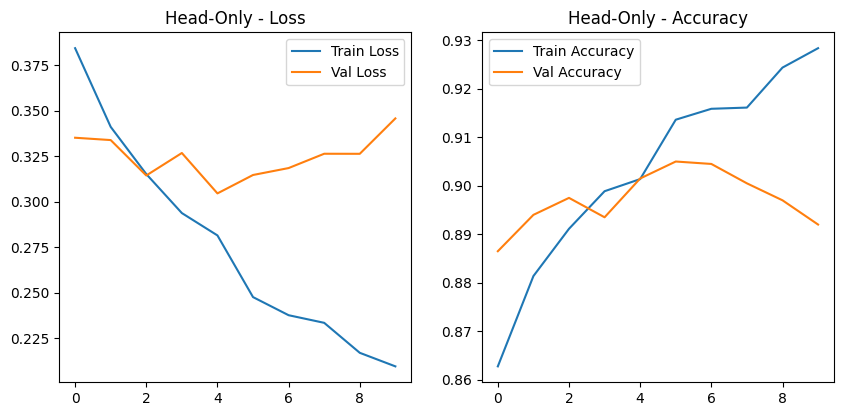

In [42]:
plt.figure(figsize=(10, 10))

# Loss
plt.subplot(2, 2, 1)
plt.plot(history_resnet_head.history['loss'], label='Train Loss')
plt.plot(history_resnet_head.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Head-Only - Loss')

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(history_resnet_head.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet_head.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Head-Only - Accuracy')


**Note**:  The head-only training phase showed strong performance from the very beginning thanks to the pretrained ImageNet features.

Validation accuracy quickly reached about 88–89% within only a few epochs, significantly outperforming the baseline CNN.

Both training and validation loss remained relatively stable during training, suggesting that the frozen ResNet50 backbone already provides highly effective feature extraction for CIFAR-10.

A small gap between training and validation accuracy appears in the later epochs, indicating the beginning of overfitting, although it remains reasonably controlled.

In [43]:
# Evaluate head-only transfer learning performance on training and test data
print("ResNet50 - Head")
# Train evaluation
eval_resnet_head_train = resnet_model.evaluate(ds_train, verbose=0)
print("Train Loss:", eval_resnet_head_train[0])
print("Train Accuracy:", eval_resnet_head_train[1])

# Test evaluation
eval_resnet_head_test = resnet_model.evaluate(ds_test, verbose=0)
print("Test Loss:", eval_resnet_head_test[0])
print("Test Accuracy:", eval_resnet_head_test[1])

ResNet50 - Head
Train Loss: 0.12429996579885483
Train Accuracy: 0.9582499861717224
Test Loss: 0.3800590932369232
Test Accuracy: 0.8827000260353088


**Note**: When training only the classification head while keeping the ResNet50 backbone frozen, the model achieved about 95.8% training accuracy and 88.3% test accuracy.

These results are significantly better than the baseline CNN, showing the effectiveness of transfer learning from ImageNet.

The gap between training and validation accuracy suggests moderate overfitting, although the model still generalizes well considering the reduced 10k training/validation subset.

### 7.3 Fine-Tuning the Full Model (10 Epochs)

Enable selective fine-tuning while keeping the early ResNet50 layers frozen.

#### Fine‑tune

In [44]:
# Unfreeze the deeper ResNet50 layers for selective fine-tuning
resnet_model.layers[1].trainable = True   # layer[1] is the ResNet50 base

# freeze the first 30 layers of ResNet
for layer in resnet_model.layers[1].layers[:-30]:
    layer.trainable = False
    
    
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 14,977,290 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

**Note**: This stage applies selective fine-tuning.

The early ResNet50 layers remain frozen because they already capture general visual features such as edges and textures.  
Only the deeper layers are unfrozen so the model can better adapt to the CIFAR-10 classes.

About 15 million parameters are trainable during this phase, while about 9 million remain frozen.

Using only partial fine-tuning helps improve performance while reducing overfitting, memory usage, and training time on local hardware.

In [45]:
# Fine-tune the unfrozen ResNet50 layers with a lower learning rate
history_resnet_ft = resnet_model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    callbacks=[lr_callback],
    verbose=1
)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.8982 - loss: 0.3046 - val_accuracy: 0.9035 - val_loss: 0.3578 - learning_rate: 1.0000e-05
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.9315 - loss: 0.1917 - val_accuracy: 0.9080 - val_loss: 0.3166 - learning_rate: 1.0000e-05
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.9484 - loss: 0.1495 - val_accuracy: 0.9130 - val_loss: 0.3000 - learning_rate: 1.0000e-05
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 343s 3s/step - accuracy: 0.9595 - loss: 0.1268 - val_accuracy: 0.9130 - val_loss: 0.3024 - learning_rate: 1.0000e-05
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.9634 - loss: 0.1044 - val_accuracy: 0.9210 - val_loss: 0.2839 - learning_rate: 1.0000e-05
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.9655 - loss: 0.0974 - val_accuracy: 0.9160 - val_loss: 0.2833 - learning_rate: 1.0000e-05
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - acc

Text(0.5, 1.0, 'Fine-Tuning - Accuracy')

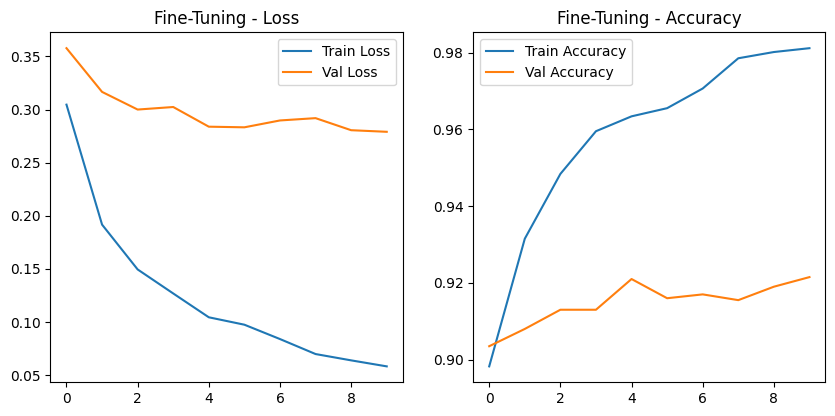

In [46]:
plt.figure(figsize=(10, 10))

# Loss
plt.subplot(2, 2, 1)
plt.plot(history_resnet_ft.history['loss'], label='Train Loss')
plt.plot(history_resnet_ft.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Fine-Tuning - Loss')

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(history_resnet_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet_ft.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Fine-Tuning - Accuracy')


**Note**: Fine-tuning slightly improved the model performance, increasing validation accuracy to about 92%.

The training accuracy continued to increase throughout the 10 epochs, reaching about 98%, while the validation accuracy remained relatively stable around 92%.

`ReduceLROnPlateau` automatically lowered the learning rate when the validation loss stopped improving, helping the model continue training more smoothly.

Overall, the results show that transfer learning with ResNet50 can achieve strong CIFAR-10 classification performance even when trained on a reduced 10k-image subset and local hardware.

### 7.4 Evaluation and Comparison of ResNet50 Models

#### Evaluate ResNet50 models

In [47]:
# Final evaluation of the fine-tuned ResNet50 model
print("ResNet50 - Fine-Tuned")
# Train evaluation
eval_resnet_ft_train = resnet_model.evaluate(ds_train, verbose=0)
print("Train Loss:", eval_resnet_ft_train[0])
print("Train Accuracy:", eval_resnet_ft_train[1])

# Test evaluation
eval_resnet_ft = resnet_model.evaluate(ds_test, verbose=0)
print("Test Loss:", eval_resnet_ft[0])
print("Test Accuracy:", eval_resnet_ft[1])

ResNet50 - Fine-Tuned
Train Loss: 0.017303384840488434
Train Accuracy: 0.9961249828338623
Test Loss: 0.3289647698402405
Test Accuracy: 0.9100000262260437


**Note**:  
The fine-tuned ResNet50 model achieved about 99.6% training accuracy and 91% test accuracy.

Compared to the head-only configuration, fine-tuning provided a small but consistent improvement in test performance.

The very high training accuracy indicates some overfitting, which is expected when training a large model on a relatively small 10k-image subset. However, the stable test accuracy suggests that data augmentation, selective freezing, and learning rate scheduling helped maintain good generalization.

Overall, the fine-tuned ResNet50 clearly outperformed the baseline CNN and demonstrated the effectiveness of transfer learning for CIFAR-10 image classification.

### 7.5 Confusion Matrix

In [83]:
# Predict probabilities on the test set
y_pred_probs = resnet_model.predict(ds_test)

# Convert probabilities to predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_labels.flatten()

157/157 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step


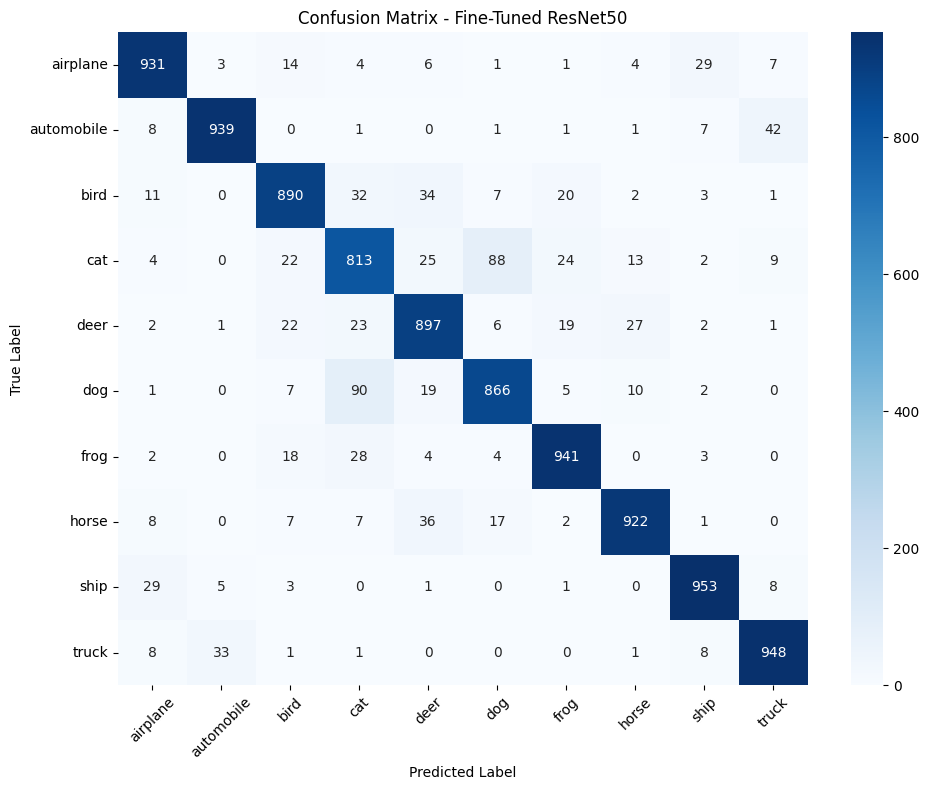

In [84]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned ResNet50")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Note**:  
The confusion matrix shows that most classes are classified correctly, with strong performance on visually distinctive categories such as airplane, ship.

Most classification errors occur between visually similar classes, especially among animals such as cat, dog, and deer.

This suggests that the model learned robust high-level visual features, while still struggling on low-resolution images with overlapping shapes and textures.

#### 7.6 Error Distribution Table

In [85]:
# Create error analysis DataFrame
errors_df = pd.DataFrame({
    "True Label": y_true,
    "Predicted Label": y_pred
})

# Keep only wrong predictions
errors_df = errors_df[errors_df["True Label"] != errors_df["Predicted Label"]]

# Convert numeric labels to class names
errors_df["True Label"] = errors_df["True Label"].map(lambda x: class_names[x])
errors_df["Predicted Label"] = errors_df["Predicted Label"].map(lambda x: class_names[x])

# Count most common confusions
error_counts = (
    errors_df
    .value_counts(["True Label", "Predicted Label"])
    .reset_index(name="Count")
)

# Display top confusions
error_counts.head(10)

,True Label,Predicted Label,Count
0,dog,cat,90
1,cat,dog,88
2,automobile,truck,42
3,horse,deer,36
4,bird,deer,34
5,truck,automobile,33
6,bird,cat,32
7,airplane,ship,29
8,ship,airplane,29
9,frog,cat,28


### 7.7 Plot Most Common Errors

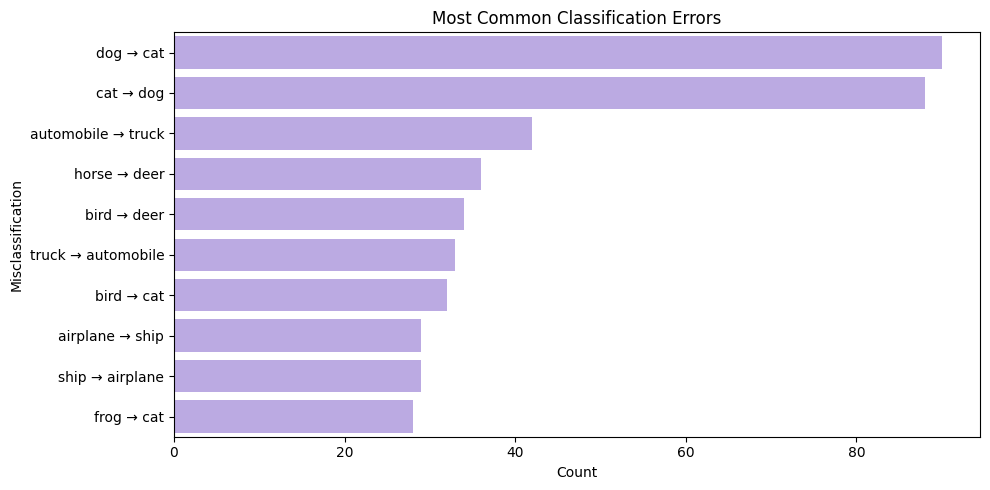

In [80]:
# Plot top 10 most common classification errors
top_errors = error_counts.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_errors,
    x="Count",
    color= '#b7a1eb',
    y=top_errors["True Label"] + " → " + top_errors["Predicted Label"],
)

plt.title("Most Common Classification Errors")
plt.xlabel("Count")
plt.ylabel("Misclassification")

plt.tight_layout()
plt.show()

***Note**:  The most common classification errors occur between visually similar classes.

The model frequently confuses cat and dog images, which is expected given the low image resolution and the similarity in textures, poses, and shapes.

Vehicle classes such as automobile and truck are also occasionally confused, especially when viewed from similar angles.

Some errors appear to be influenced by background and color similarities. For example, airplane and ship images are sometimes confused because both classes often contain large blue regions associated with sky or water backgrounds.

Overall, the error distribution suggests that the model learned meaningful visual representations, while still struggling with low-resolution images and overlapping class features.

### 7.8 Misclassified Images

In [56]:
# Find misclassified samples
misclassified_idx = np.where(y_true != y_pred)[0]

print("Number of misclassified images:", len(misclassified_idx))

Number of misclassified images: 900


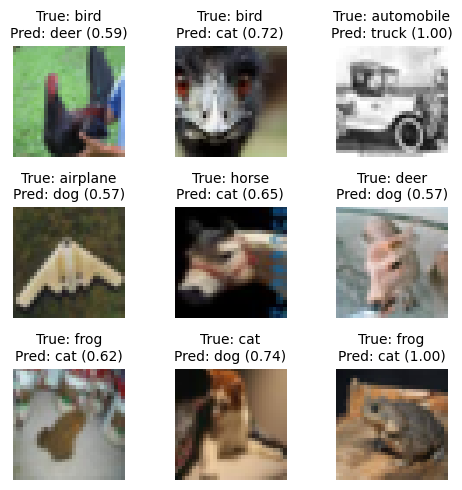

In [ ]:
# Plot misclassified images
plt.figure(figsize=(5, 5))

for i, idx in enumerate(misclassified_idx[:9]):
    
    plt.subplot(3, 3, i + 1)
    
    # Show original test image
    plt.imshow(test_images_32[idx])
    
    # Labels
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    
    # Prediction confidence
    confidence = y_pred_probs[idx][y_pred[idx]]
    
    plt.title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})",
        fontsize=10
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

**Note**: The misclassified examples show that many prediction errors occur on visually ambiguous or low-quality images.

Several samples are blurry, partially occluded, poorly illuminated, or contain backgrounds that resemble other classes. In many cases, the incorrect prediction is still semantically understandable. For example, cats and dogs often share similar textures and shapes at very low resolution.

Some errors are also caused by unusual framing and viewpoints. Close-up or partially cropped objects may remove important contextual information that normally helps the model identify the correct class.

In one example, a close-up bird image was misclassified as a cat because only part of the face was visible, while the overall body shape and surrounding context were missing. Humans can still recognize the object semantically, but the model struggles because it mainly relies on local visual patterns.

Overall, these examples highlight the difficulty of learning robust visual representations from low-resolution CIFAR-10 images.

## 8. Final Comparison and Insights

### 8.1 Model Comparison

The project compared two different approaches for CIFAR-10 image classification:

1. A small custom CNN trained directly on the original 32×32 images.
2. A transfer learning approach based on ResNet50 pretrained on ImageNet.

The baseline CNN achieved moderate performance with about 60% test accuracy.  
Although the model successfully learned useful image features, its limited depth and relatively small capacity reduced its ability to generalize on more complex samples.

The ResNet50 transfer learning approach significantly improved performance.  
Even when training only the custom classification head, the model reached nearly 89% test accuracy. After selective fine-tuning of the deeper layers, the final test accuracy increased to about 91%.

These results demonstrate the strong advantage of pretrained deep architectures over small CNNs, especially when working with limited datasets.


### 8.2 Main Findings

Several important observations emerged during the project:

- Transfer learning greatly improved classification performance compared to training a CNN from scratch.
- Pretrained ImageNet features transferred effectively to CIFAR-10 despite the lower image resolution.
- Data augmentation helped reduce overfitting and improved model generalization.
- Selective fine-tuning provided additional performance gains while keeping training manageable on local hardware.
- Learning rate scheduling (`ReduceLROnPlateau`) improved training stability during fine-tuning.

### 8.3 Limitations

The project also had several limitations:

- Only a reduced subset of 10,000 training images was used.
- Training was limited to 10 epochs for each stage due to local hardware constraints.
- ResNet50 is a very large architecture for CIFAR-10, making training time relatively long.

### 8.4 Possible Improvements

Future improvements could include:

- Training on the full CIFAR-10 dataset.
- Using longer fine-tuning schedules.
- Experimenting with additional augmentation techniques.
- Comparing ResNet50 with lighter architectures such as MobileNet or EfficientNet.
- Applying EarlyStopping to further control overfitting.


### 8.5 Final Conclusion

Overall, the project successfully demonstrated how transfer learning with ResNet50 can achieve strong image classification performance on CIFAR-10 even with limited computational resources.

The final fine-tuned model clearly outperformed the baseline CNN and showed that pretrained deep learning models can generalize effectively on smaller datasets when combined with preprocessing, augmentation, and selective fine-tuning.

### 9. Presentation Plots

In [75]:
sample_image = train_images_32[3]

In [78]:
# Original image
original = sample_image

# Horizontal flip
flip = tf.image.flip_left_right(sample_image)

# Random crop / zoom
crop = tf.image.random_crop(
    tf.image.resize(sample_image, (40, 40)),
    size=[32, 32, 3]
)

# Brightness variation
bright = tf.image.random_brightness(sample_image, max_delta=0.2)

# Contrast variation
contrast = tf.image.random_contrast(sample_image, lower=0.3, upper=2.5)

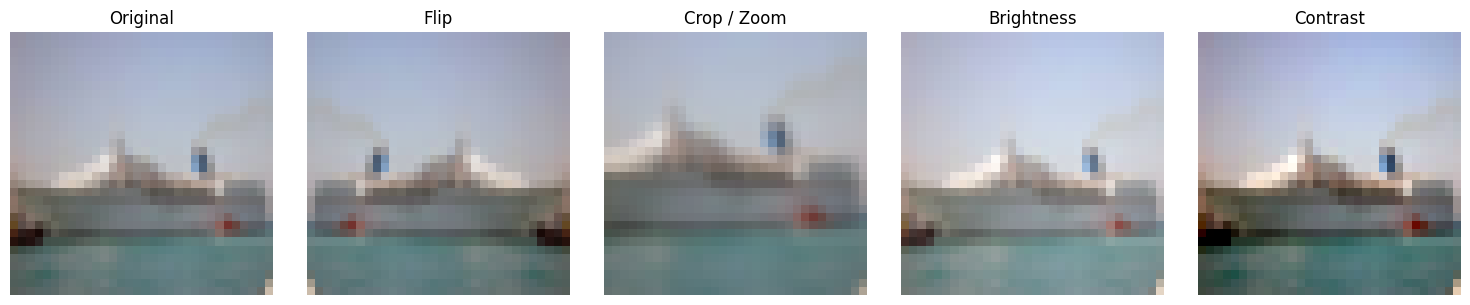

In [79]:
images = [original, flip, crop, bright, contrast]

titles = [
    "Original",
    "Flip",
    "Crop / Zoom",
    "Brightness",
    "Contrast"
]

plt.figure(figsize=(15, 3))

for i in range(len(images)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(tf.clip_by_value(images[i], 0, 1))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()